In [1]:
import zeus21
import eMCMC
import estats
from matplotlib.ticker import MaxNLocator
import eplots
Plotting = eplots.Plotting()
import importlib

In [207]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

In [208]:
# Set hyperparameters
scale = np.array([1, 1, 1, 1, 1, 1000])
labels = [r'$\log(M_c)$', r"$\alpha$", r"$\beta$", r"$\log(\epsilon_0)$", r'$\sigma_{\rm{UV}, 0}$', r'$d\sigma_{\rm{UV}}/dM_{h}$']
params1 = np.array([12, 0.6, -0.5, -1, 0,.01]) * scale
lowers = np.array([9, 0, -4,  -5, 0, -1]) * scale
uppers = np.array([16, 4, 0, 1, 3, 1]) * scale

In [209]:
# Initalize class to test just the mass dependence
my_UVLF = eMCMC.UVLF(datHST, params1, lowers, uppers, scale=scale, time_dependence = False, mass_dependence = False)

In [210]:
# Get initial positions for all the walkers by running a short MCMC
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [211]:
# Run MCMC
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)

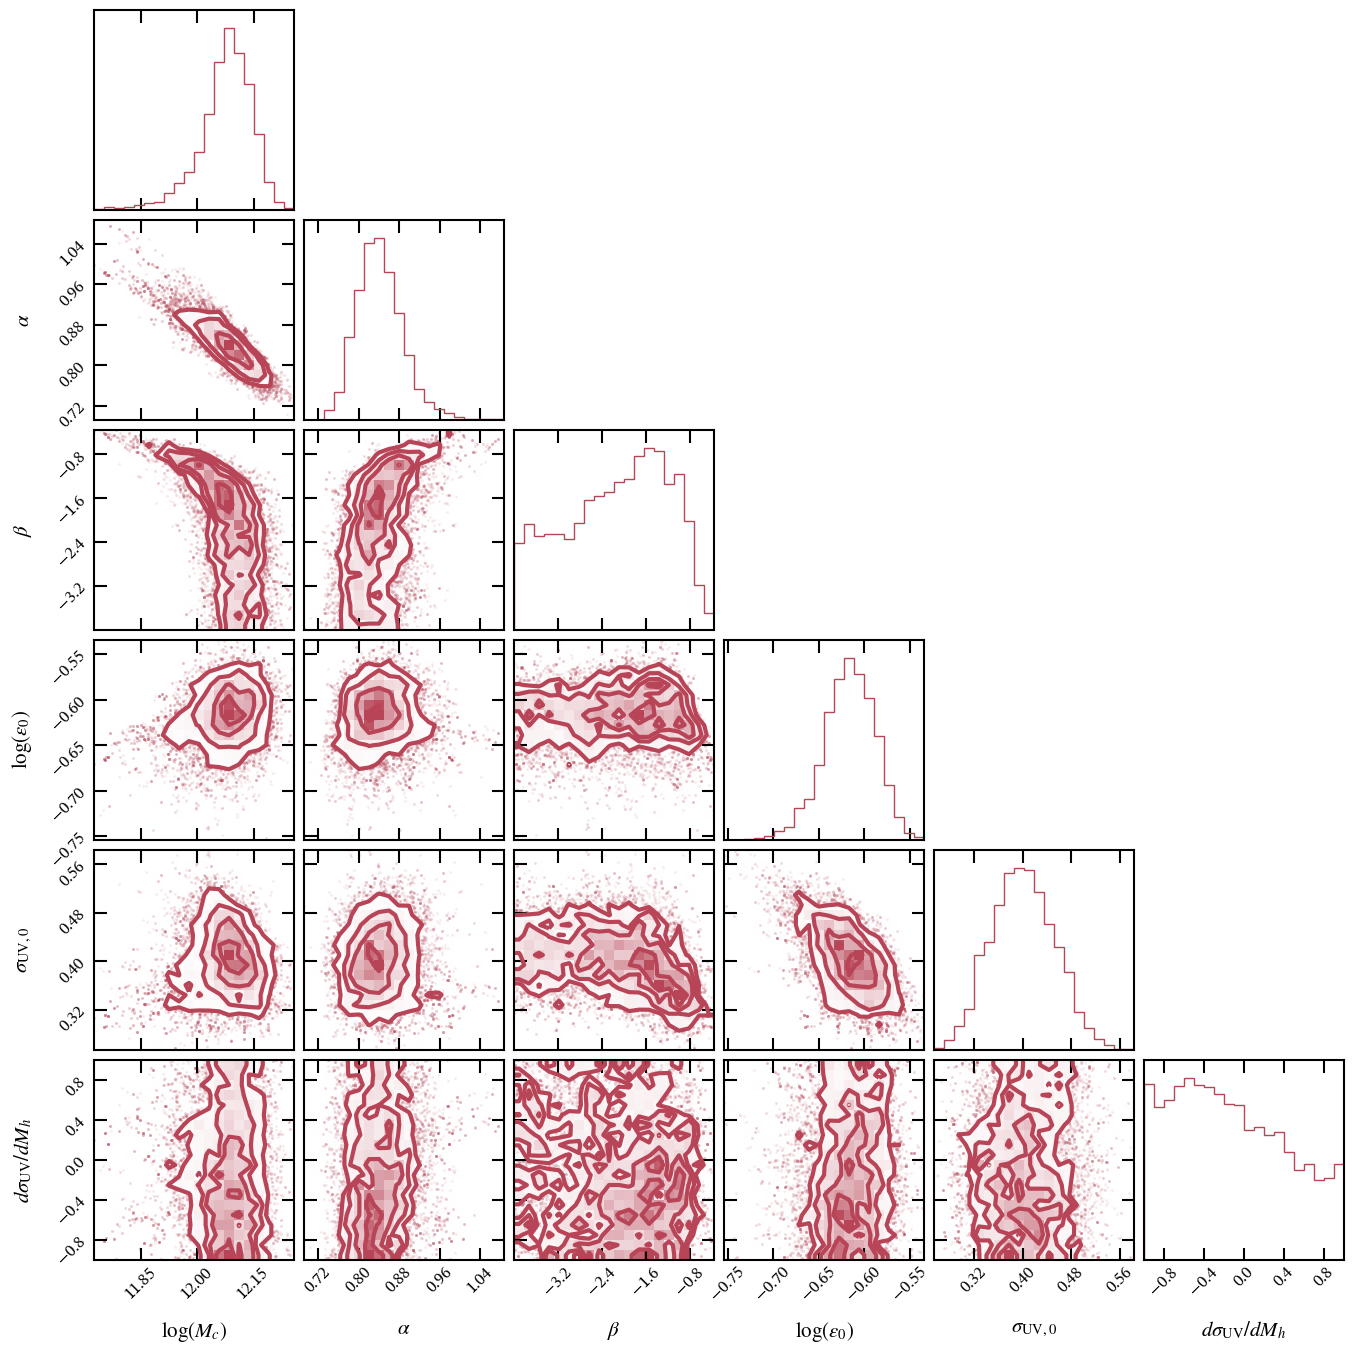

In [212]:
corner = Plotting.plot_corner(samples, scale, labels)

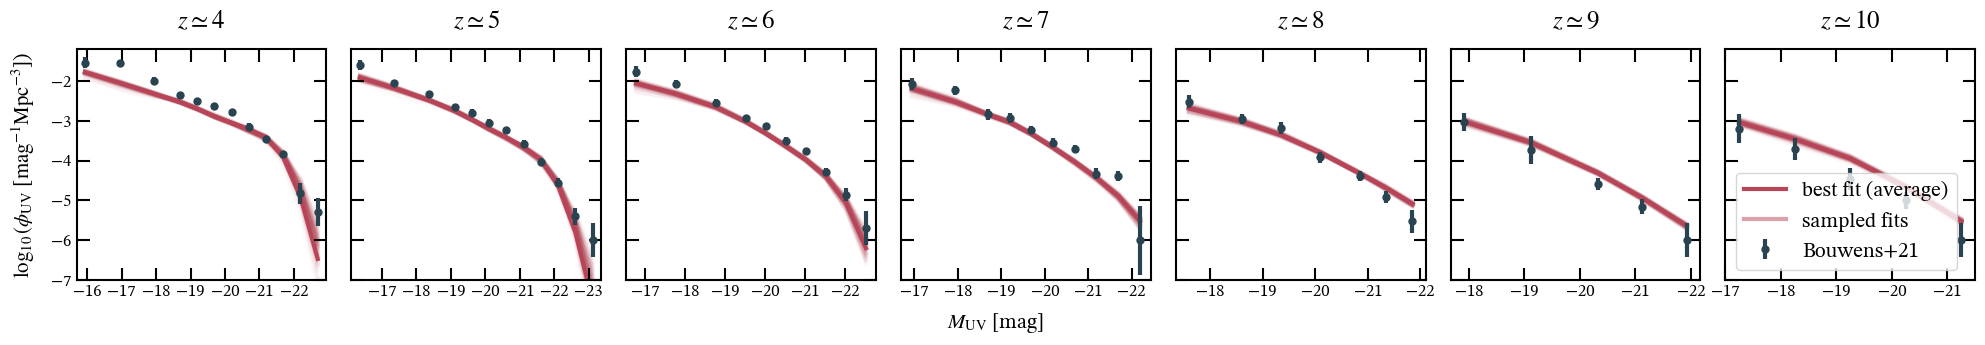

In [214]:
ev_sig = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, 
        title = '')

# <span style = 'color:red'> Test sigma(M): <span>

In [31]:
z = datHST[0][0]
zwidth = datHST[0][1]
MUVcenters = datHST[0][2]
MUVwidth = datHST[0][5]
ydat = datHST[0][3]
yerr = datHST[0][4]

In [32]:
CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
CosmoParams, _, _, HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)

In [201]:
evolv_sigUV = (1 + (.5*(np.log10(HMFintclass.Mhtab)-11)))
evolv_sigUV = np.maximum(evolv_sigUV, 0)
astroparams_test = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = evolv_sigUV)
UVLF_test = zeus21.UVLFs.UVLF_binned(astroparams_test,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

In [202]:
astroparams_std = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = 1) 
UVLF_std = zeus21.UVLFs.UVLF_binned(astroparams_std,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

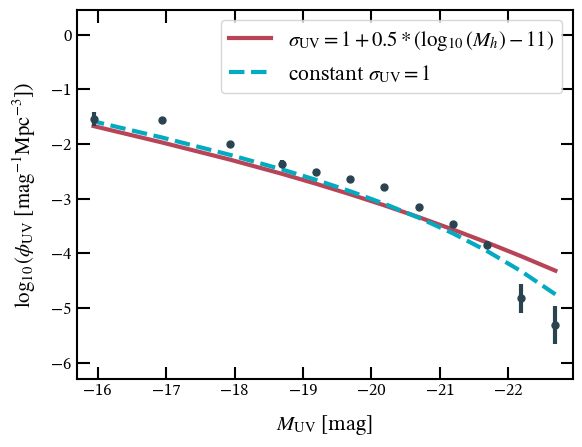

In [205]:
fig, ax = plt.subplots()

ax.plot(MUVcenters, np.log10(UVLF_test), label = r'$\sigma_{\rm{UV}} = 1 + 0.5*(\log_{10}(M_h) - 11)$' )
ax.plot(MUVcenters, np.log10(UVLF_std), label = r'constant $\sigma_{\rm{UV}} = 1$', linestyle = '--')


ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)

ax.errorbar(MUVcenters, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
               color = Plotting.navy)
ax.invert_xaxis()
ax.set_xlim(np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25)
ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

ax.legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/sigma(M_h).png', bbox_inches = 'tight')